In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("pharmeasy.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                320 non-null    object
 1   category             320 non-null    object
 2   price                320 non-null    object
 3   no_of_ratings_given  261 non-null    object
 4   product_offer        313 non-null    object
dtypes: object(5)
memory usage: 12.6+ KB


In [4]:
df.head()

,title,category,price,no_of_ratings_given,product_offer
0,Pharmeasy Coenzyme Q10 (Coq10) 200mg With Pipe...,Must Haves,₹770.65,NaN,53% OFF
1,Pharmeasy Diabetic Protein Powder French Vanil...,Must Haves,₹382.27,(60ratings),57% OFF
2,Everherb Karela Jamun Juice - Helps Maintains ...,Must Haves,₹160.85,(2174ratings),57% OFF
3,Everherb Diabetic Care Juice-13 Potent Herbs -...,Must Haves,₹230.42,(1429ratings),59% OFF
4,Pharmeasy Pill Box Organizer,Must Haves,₹234.53,(905ratings),53% OFF


In [5]:
df.fillna({"no_of_ratings_given":0},inplace=True)

In [6]:
df["no_of_ratings_given"].isna().sum()

0

In [7]:
df.fillna({"product_offer":0},inplace=True)

In [8]:
df.isna().sum()

title                  0
category               0
price                  0
no_of_ratings_given    0
product_offer          0
dtype: int64

In [9]:
df.head()

,title,category,price,no_of_ratings_given,product_offer
0,Pharmeasy Coenzyme Q10 (Coq10) 200mg With Pipe...,Must Haves,₹770.65,0,53% OFF
1,Pharmeasy Diabetic Protein Powder French Vanil...,Must Haves,₹382.27,(60ratings),57% OFF
2,Everherb Karela Jamun Juice - Helps Maintains ...,Must Haves,₹160.85,(2174ratings),57% OFF
3,Everherb Diabetic Care Juice-13 Potent Herbs -...,Must Haves,₹230.42,(1429ratings),59% OFF
4,Pharmeasy Pill Box Organizer,Must Haves,₹234.53,(905ratings),53% OFF


In [10]:
df["category"]=df["category"].str.lower()

In [11]:
df.head()

,title,category,price,no_of_ratings_given,product_offer
0,Pharmeasy Coenzyme Q10 (Coq10) 200mg With Pipe...,must haves,₹770.65,0,53% OFF
1,Pharmeasy Diabetic Protein Powder French Vanil...,must haves,₹382.27,(60ratings),57% OFF
2,Everherb Karela Jamun Juice - Helps Maintains ...,must haves,₹160.85,(2174ratings),57% OFF
3,Everherb Diabetic Care Juice-13 Potent Herbs -...,must haves,₹230.42,(1429ratings),59% OFF
4,Pharmeasy Pill Box Organizer,must haves,₹234.53,(905ratings),53% OFF


In [12]:
#Cleaning price
df["price"]=df["price"].str.replace("₹","")
df["price"]=df["price"].str.replace("MRP","")

In [13]:
df["price"]=df["price"].astype(float)

In [14]:
df["price"].dtype

dtype('float64')

In [15]:
df.head()

,title,category,price,no_of_ratings_given,product_offer
0,Pharmeasy Coenzyme Q10 (Coq10) 200mg With Pipe...,must haves,770.65,0,53% OFF
1,Pharmeasy Diabetic Protein Powder French Vanil...,must haves,382.27,(60ratings),57% OFF
2,Everherb Karela Jamun Juice - Helps Maintains ...,must haves,160.85,(2174ratings),57% OFF
3,Everherb Diabetic Care Juice-13 Potent Herbs -...,must haves,230.42,(1429ratings),59% OFF
4,Pharmeasy Pill Box Organizer,must haves,234.53,(905ratings),53% OFF


In [16]:
#Cleaning no_of_ratings_given
df["no_of_ratings_given"] = df["no_of_ratings_given"].astype(str)

In [17]:
df["no_of_ratings_given"] = df["no_of_ratings_given"].str.replace("(", "")
df["no_of_ratings_given"] = df["no_of_ratings_given"].str.replace("ratings", "")
df["no_of_ratings_given"] = df["no_of_ratings_given"].str.replace(")", "")

In [18]:
df["no_of_ratings_given"] = pd.to_numeric(df["no_of_ratings_given"],errors="coerce")

In [19]:
df["no_of_ratings_given"] = df["no_of_ratings_given"].fillna(0).astype(int)

In [20]:
df.head()

,title,category,price,no_of_ratings_given,product_offer
0,Pharmeasy Coenzyme Q10 (Coq10) 200mg With Pipe...,must haves,770.65,0,53% OFF
1,Pharmeasy Diabetic Protein Powder French Vanil...,must haves,382.27,60,57% OFF
2,Everherb Karela Jamun Juice - Helps Maintains ...,must haves,160.85,2174,57% OFF
3,Everherb Diabetic Care Juice-13 Potent Herbs -...,must haves,230.42,1429,59% OFF
4,Pharmeasy Pill Box Organizer,must haves,234.53,905,53% OFF


In [21]:
#Cleaning product_offer
df["product_offer"]=df["product_offer"].str.replace("% OFF","")

In [22]:
df["product_offer"].head()

0    53
1    57
2    57
3    59
4    53
Name: product_offer, dtype: object

In [23]:
df["product_offer"]=pd.to_numeric(df["product_offer"])

In [24]:
df["product_offer"]=df["product_offer"].fillna(0).astype(int)

In [25]:
df["product_offer"].dtype

dtype('int32')

In [26]:
df.head()

,title,category,price,no_of_ratings_given,product_offer
0,Pharmeasy Coenzyme Q10 (Coq10) 200mg With Pipe...,must haves,770.65,0,53
1,Pharmeasy Diabetic Protein Powder French Vanil...,must haves,382.27,60,57
2,Everherb Karela Jamun Juice - Helps Maintains ...,must haves,160.85,2174,57
3,Everherb Diabetic Care Juice-13 Potent Herbs -...,must haves,230.42,1429,59
4,Pharmeasy Pill Box Organizer,must haves,234.53,905,53


In [27]:
#Segregating products according to price
conditions=[df["price"]<300,(df["price"]>=300) & (df["price"]<=800),df["price"]>800]
labels=["Budget","Mid-Range","Premium"]
df["price_segment"]=np.select(conditions,labels,default="Unknown")

In [28]:
df.head()

,title,category,price,no_of_ratings_given,product_offer,price_segment
0,Pharmeasy Coenzyme Q10 (Coq10) 200mg With Pipe...,must haves,770.65,0,53,Mid-Range
1,Pharmeasy Diabetic Protein Powder French Vanil...,must haves,382.27,60,57,Mid-Range
2,Everherb Karela Jamun Juice - Helps Maintains ...,must haves,160.85,2174,57,Budget
3,Everherb Diabetic Care Juice-13 Potent Herbs -...,must haves,230.42,1429,59,Budget
4,Pharmeasy Pill Box Organizer,must haves,234.53,905,53,Budget


In [29]:
#Average price per segment
df.groupby("price_segment")["price"].mean()

price_segment
Budget        174.516354
Mid-Range     493.780897
Premium      2390.846393
Name: price, dtype: float64

In [30]:
df.groupby("price_segment")["price"].count()

price_segment
Budget       181
Mid-Range     78
Premium       61
Name: price, dtype: int64

In [31]:
#Average price per category,Median price per category
df.groupby("category")["price"].agg(["mean","median"]).sort_values(by="mean",ascending=False)

,mean,median
category,,
explore more,2724.2250,1039.350
sports nutrition,2250.5020,1295.460
sexual wellness,900.8980,331.650
healthcare devices,850.9805,841.825
heart care,607.2450,363.600
ayurvedic care,525.2125,357.890
skin care,487.5140,503.475
diabetes essentials,479.9605,280.085
mother and baby care,385.9595,275.090


In [32]:
#Average ratings per category
df.groupby("category")["no_of_ratings_given"].mean()

category
ayurvedic care             168.20
diabetes essentials        882.60
explore more                94.90
health concerns            617.55
health food and drinks     538.50
healthcare devices         721.95
heart care                  62.85
mobility & elderly care    383.10
mother and baby care       184.20
must haves                 570.05
personal care              382.90
sexual wellness             31.75
skin care                  212.50
sports nutrition            19.55
vitamin store              559.55
winter store               546.80
Name: no_of_ratings_given, dtype: float64

In [33]:
#Number of products per category
df.groupby("category")["title"].count()

category
ayurvedic care             20
diabetes essentials        20
explore more               20
health concerns            20
health food and drinks     20
healthcare devices         20
heart care                 20
mobility & elderly care    20
mother and baby care       20
must haves                 20
personal care              20
sexual wellness            20
skin care                  20
sports nutrition           20
vitamin store              20
winter store               20
Name: title, dtype: int64

In [34]:
#Average ratings of discounted vs non-discounted products
def offer_bucket(product_offer):
    if product_offer==0 or pd.isna(product_offer):
        return "No Offer"
    else:
        return "Offer applied"
        
df.groupby(df["product_offer"].apply(offer_bucket))["no_of_ratings_given"].mean()

product_offer
No Offer         163.285714
Offer applied    378.261981
Name: no_of_ratings_given, dtype: float64

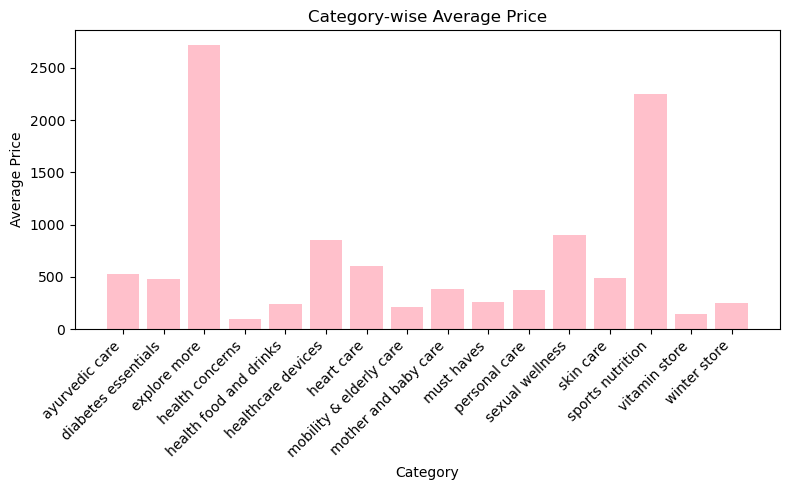

In [35]:
#Category-wise Average Price (Bar Chart)
mean_price = df.groupby("category")["price"].mean()

x_pos = range(len(mean_price))

plt.figure(figsize=(8, 5))
plt.bar(x_pos, mean_price.values, color="pink")
plt.xticks(x_pos, mean_price.index, rotation=45, ha="right")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.title("Category-wise Average Price")
plt.tight_layout()
plt.show()

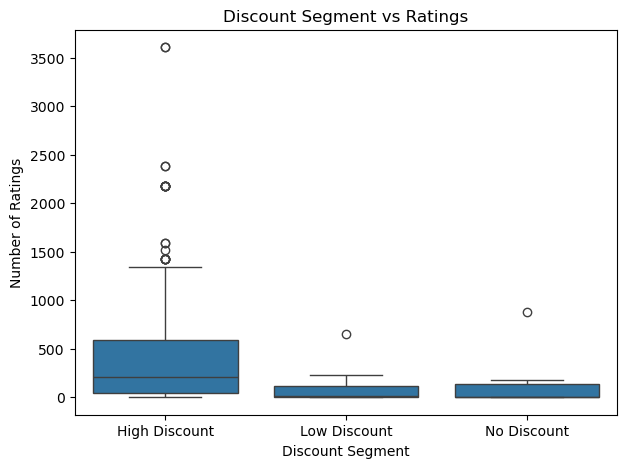

In [36]:
#Discount Segment vs Ratings (Box Plot)
def offer_bucket(product_offer):
    if product_offer == 0 or pd.isna(product_offer):
        return "No Discount"
    elif product_offer <= 10:
        return "Low Discount"
    else:
        return "High Discount"

df["discount_segment"] = df["product_offer"].apply(offer_bucket)

plt.figure(figsize=(7,5))
sns.boxplot(
    x="discount_segment",
    y="no_of_ratings_given",
    data=df
)
plt.title("Discount Segment vs Ratings")
plt.xlabel("Discount Segment")
plt.ylabel("Number of Ratings")
plt.show()

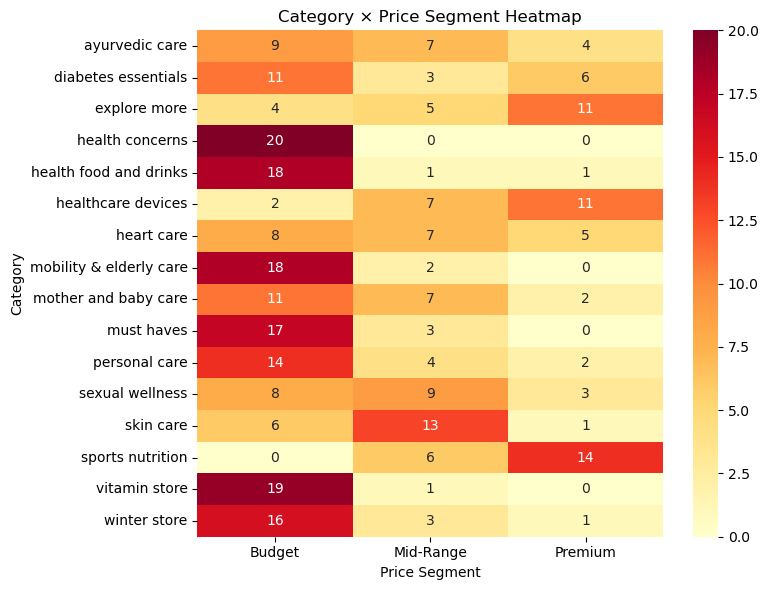

In [37]:
#Category × Price Segment Heatmap
heatmap_data = pd.crosstab(
    df["category"],
    df["price_segment"]
)

plt.figure(figsize=(8,6))
sns.heatmap(
    heatmap_data,
    annot=True,        # show numbers inside cells
    fmt="d",           # integer format
    cmap="YlOrRd"      # yellow → red color scale
)

plt.title("Category × Price Segment Heatmap")
plt.xlabel("Price Segment")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [38]:
df.to_csv("pharmeasy1.csv", index=False)